In [29]:
import os
import re

import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import healpy as hp
import camb

from ksw import Cosmology, Data, radial_functional as rf

%matplotlib inline

These are the functions that compute $a_{lm}^{NG,loc'}$

In [30]:
def interpolate_ells(func, ells_sparse, ls):
    # ells_sparse are the ells used in the transfer function
    # ls are the ells used in the healpy alms
    # func is a function of ells_sparse
    # returns (nr, npol, nls)
    gen = interp1d(ells_sparse, func, kind='cubic', axis=1, bounds_error=False, fill_value=0)
    return gen(ls).swapaxes(1, 2)

def get_delta_phi():
    # primordial normalization
    return 2 * np.pi ** 2 * 2.13e-09 * (3 / 5)**2

def get_alpha_l(tr_ell_k, ks, radii, ells):
    # radial func does f_ell^X(r) = (2/pi) int k^2 dk f(k) transfer^X_ell(k) j_ell(k r)
    # alpha_l = (2/pi) int k^2 dk transfer^X_ell(k) j_ell(k r)
    # returns shape (nr, nell, npol)
    
    f_k = np.ones((len(ks), 1))
    return rf.radial_func(f_k, tr_ell_k, ks, radii, ells).squeeze()

def get_beta_l(tr_ell_k, ks, radii, ells):
    # radial func does f_ell^X(r) = (2/pi) int k^2 dk f(k) transfer^X_ell(k) j_ell(k r)
    # beta_l = (2/pi) int k^-1 dk delta_phi(k) transfer^X_ell(k) j_ell(k r)
    # returns shape (nr, nell, npol)

    f_k = np.swapaxes([ks**-3 * get_delta_phi()], 0, -1)
    return rf.radial_func(f_k, tr_ell_k, ks, radii, ells).squeeze()

def a_lm_ng(alms, data, nside, r_min=1, r_max=15000, r_res=10):
    lmax_alm = hp.Alm.getlmax(alms.shape[-1])

    # These values are sparse in ell
    c_ells = data.cosmology.c_ell['unlensed_scalar']['ells']
    tr_ell_k = data.cosmology.transfer['tr_ell_k']
    ells = data.cosmology.transfer['ells']
    ks = data.cosmology.transfer['k']

    radii = np.linspace(r_min, r_max, r_res)
    alpha_ell = get_alpha_l(tr_ell_k, ks, radii, ells)
    beta_ell = get_beta_l(tr_ell_k, ks, radii, ells)

    # interpolate to the ells used in the alms, non-sparce
    ls, _ = hp.Alm.getlm(lmax_alm)
    alpha_l = interpolate_ells(alpha_ell, ells, ls)
    bl_div_cl = interpolate_ells(beta_ell / c_ells[None, ells, None], ells, ls)

    dr = radii[1] - radii[0]
    alm_ng = np.empty((radii.shape[0], alms.shape[0], alms.shape[1]), dtype=np.complex128)
    for r in range(radii.shape[0]):
        for p in range(alms.shape[0]):
            Balm = hp.almxfl(alms[p], bl_div_cl[r, p, :]) # = beta_l / c_ell * a_lm
            B2 = hp.alm2map(Balm, nside=nside, lmax=lmax_alm, mmax=None, pol=False, pixwin=False, fwhm=0, sigma=None)**2

            inner = hp.map2alm(B2, lmax=lmax_alm, mmax=None, pol=False)
            alm_ng[r, p] = dr * radii[r]**2 * alpha_l[r, p, :] * inner

    return np.sum(alm_ng, axis=0)

In [31]:
def cutSqPatches(fullsky_map, img_size, side_deg, num_patches):
    Tmap_datat = np.zeros((num_patches//2, int(img_size), int(img_size)))
    Tmap_datab = np.zeros((num_patches//2, int(img_size), int(img_size)))

    pl.ioff()
    for counter in range(num_patches//2):
        Tmap_datat[counter] = np.ma.getdata(hp.cartview(fullsky_map, fig=0, xsize=img_size, ysize=img_size, rot=[0, 0], lonra=[side_deg*counter, side_deg*(counter+1)], latra=[0, 10],
                                                        title="CartView", unit="mK", format="%.2g", return_projected_map=True))
        Tmap_datab[counter] = np.ma.getdata(hp.cartview(fullsky_map, fig=1, xsize=img_size, ysize=img_size, rot=[0, 0], lonra=[side_deg*counter, side_deg*(counter+1)], latra=[-10, 0],
                                                        title="CartView", unit="mK", format="%.2g", return_projected_map=True))
    pl.close('all')
    pl.ion()
    
    return np.concatenate((Tmap_datat, Tmap_datab))

def run_simulations(num_sim, 
                    cosmo_params, 
                    fnl_range, 
                    lmax, 
                    nside,
                    side_deg, 
                    num_patches, 
                    pol="T"):
    
    print(f"Running {num_sim} simulations with fnl in range {fnl_range}, and polarizations {pol}...")
    print("Init Cosmology...")
    camb_params_obj = camb.set_params(**cosmo_params)
    cosmo = Cosmology(camb_params_obj, verbose=True)
    cosmo.compute_transfer(cosmo_params['max_l'])
    cosmo.compute_c_ell()
    print("Done!")
    
    nell = lmax + 1
    n_ell = np.ones(nell, dtype=float)      # noise
    b_ell = np.ones(nell)                   # beam
    data = Data(lmax, n_ell, b_ell, pol, cosmo) 
    
    print("Computing alm...", end='')
    alm = data.compute_alm_sim(lens_power=False)
    alm_ng = a_lm_ng(alm, data, nside)
    print("Done!")

    print("Running simulations...")
    # TODO support pol
    patches = np.empty((0, nside, nside))
    fnls = np.random.uniform(fnl_range[0], fnl_range[1], num_sim).astype(np.float32)
    for i in range(num_sim):
        alm_prime = alm + fnls[i] * alm_ng
        
        cmb_map = hp.sphtfunc.alm2map(alm_prime[0], nside, lmax=lmax, mmax=None, pol=False, pixwin=False, fwhm=0, sigma=None)
        patches = np.concatenate((patches, cutSqPatches(cmb_map, nside, side_deg, num_patches)))

        if (i + 1) % 100 == 0:
            print(f"...Finished {i+1} simulations...")
            
    print("Done!")
    return (fnls, patches)

Set of CAMB parameters, need to match the variable names used in CAMB

See: https://camb.readthedocs.io/en/latest/model.html

> Some of these parameters will be overwritten by the KSW Cosmology class (hard coded)
>
> Enable verbose in cosmo init to see which ones. 
> Will need to change the code to set these after init

See: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [32]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000, # should be higher then lmax below, will get c_l_max > lmax error otherwise, for some reason
}

The actual data generation settings.

lmax and nside are the most likely to effect preformance. 

Might have memory issues with too high values.

lmax >= 300 is enforced by the ksw code due to errors

nside should be of type 2\*\*n to help optimize the computations
npix = 12\*nside\*\*2

In [33]:
# You will get a warning if lmax > 4*nside
lmax = 2500 # used for computing, max_l is for internal

fnl_range=(-1000, 1000)

## simulations settings
# Remeber: Total patches will be num_sim * num_patches
num_sim = 10 
num_patches = 10
nside=1024
patch_side_deg = 10

In [34]:
fnls, patches = run_simulations(num_sim, 
                                cosmo_params, 
                                fnl_range, 
                                lmax, 
                                nside,
                                patch_side_deg, 
                                num_patches)

Running 10 simulations with fnl in range (-1000, 1000), and polarizations T...
Init Cosmology...
Updated CAMB param: DoLateRadTruncation from True to False.
Updated CAMB param: AccuracyBoost from 1.0 to 2.
Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: lSampleBoost from 1.0 to 2.
Updated CAMB param: lAccuracyBoost from 1.0 to 2.
Updated CAMB param: AccurateBB from False to True.
Done!
Computing alm...Done!
Running simulations...
Done!


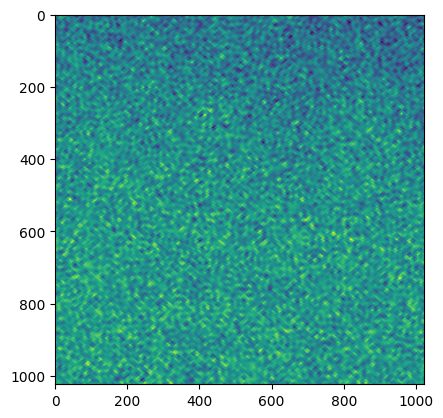

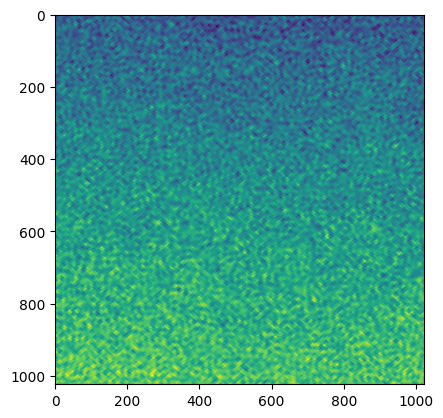

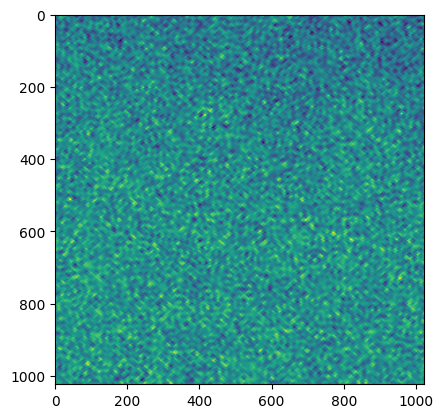

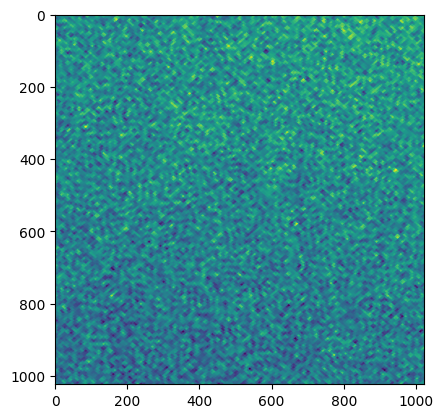

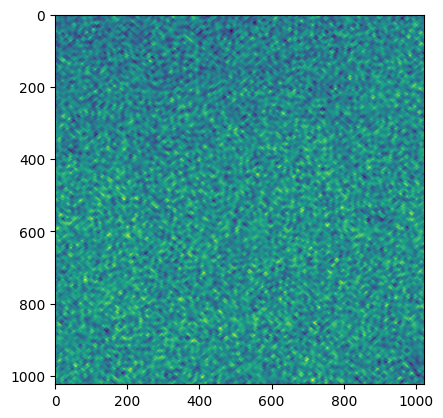

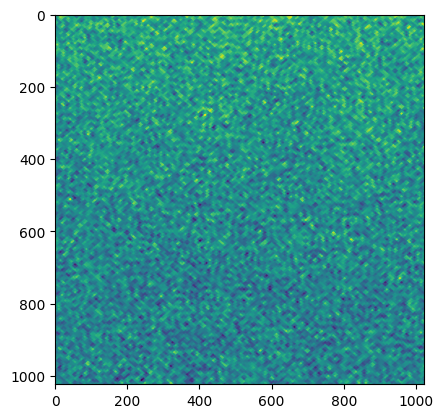

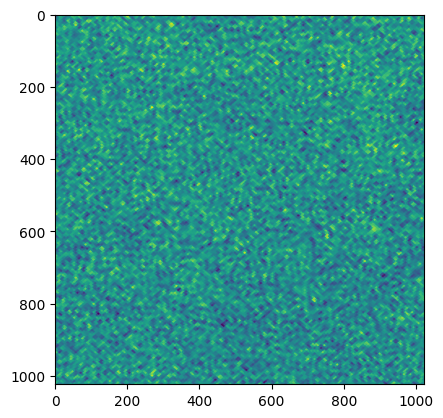

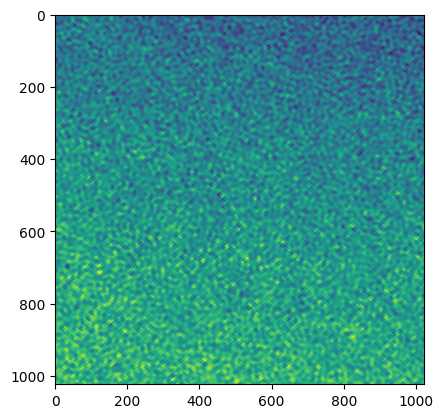

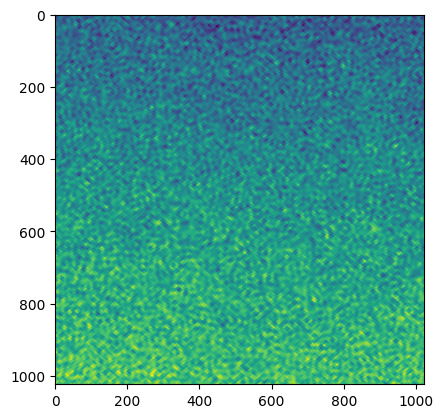

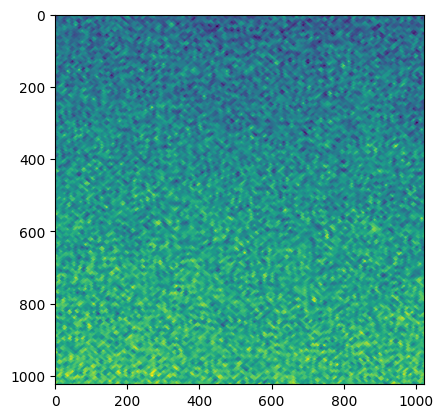

In [35]:
# Plot some of the patches
random_indices = np.random.choice(num_patches * num_sim, 10, replace=False)
for i in random_indices:
    plt.imshow(patches[i])
    plt.show()

In [38]:
def _save(dir, filename, data):
    if not os.path.exists(dir):
        os.makedirs(dir)
    print(f"Saving to {dir}/{filename}...", end=" ")
    with open(f"{dir}/{filename}", "xb") as f:
        np.save(f, data)
    print("Done!")

# Data Settings
base_name = f'{nside}-{num_sim}x{num_patches}_fnl{fnl_range[0]}-{fnl_range[1]}'
data_file = f"{base_name}"
data_dir=f'data/ksw/{base_name}'

# Create data dir if it doesn't exist
# If it exists we clean up the data files to prevent possible issues
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')
    # pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
    pattern = re.compile(f"{base_name}.npy")
    for file in os.listdir(data_dir):
        if pattern.match(file):
            file_path = os.path.join(data_dir, file)
            os.remove(file_path)
            print(f"Deleted data file: {file_path}")

_save(data_dir, f'{data_file}.npy', {'fnls':fnls, 'patches':patches})
print("Done!")

Reusing directory data/ksw/1024-10x10_fnl-1000-1000
Deleted data file: data/ksw/1024-10x10_fnl-1000-1000/1024-10x10_fnl-1000-1000.npy
Saving to data/ksw/1024-10x10_fnl-1000-1000/1024-10x10_fnl-1000-1000.npy... Done!
